# Autoencoder for Image Denoising using Deep Learning

## Week 6 Assessment

### Objective

The objective of this project is to build a **Convolutional Denoising Autoencoder** capable of removing artificial Gaussian noise from handwritten digit images in the MNIST dataset.

Unlike a conventional autoencoder that simply reconstructs its input, a denoising autoencoder learns to recover the original clean image from a corrupted version. During training, noisy images are provided as inputs while the corresponding clean images serve as target outputs.

This project demonstrates how deep learning can be applied to image restoration tasks while preserving the structural information of handwritten digits.

---

### Workflow

1. Load and preprocess the MNIST dataset.
2. Add artificial Gaussian noise to the images.
3. Build a Convolutional Denoising Autoencoder.
4. Train the model using noisy images as input and clean images as targets.
5. Evaluate the model on unseen test images.
6. Visualize the denoising performance.
7. Analyze the results and observations.

In [11]:
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import datasets, transforms

from torch.utils.data import DataLoader, TensorDataset

from sklearn.metrics import mean_squared_error

## Load and Preprocess the MNIST Dataset

The MNIST dataset contains grayscale handwritten digit images of size **28 × 28 pixels**.

Each pixel value ranges from **0 to 255**. To improve training stability, the images are normalized to the range **[0,1]** using the `ToTensor()` transformation.

In [12]:
transform = transforms.ToTensor()

train_dataset = datasets.MNIST(root='./data',train=True,download=True,transform=transform)

test_dataset = datasets.MNIST(root='./data',train=False,download=True,transform=transform)


In [13]:
print("Training Images :", len(train_dataset))
print("Testing Images  :", len(test_dataset))

Training Images : 60000
Testing Images  : 10000


## Visualizing Sample Images

Before introducing noise, it is important to inspect a few original handwritten digit images from the dataset.

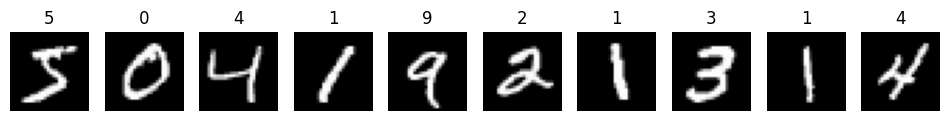

In [14]:
plt.figure(figsize=(12,2))

for i in range(10):

    image, label = train_dataset[i]

    plt.subplot(1,10,i+1)
    plt.imshow(image.squeeze(), cmap='gray')
    plt.title(label)
    plt.axis('off')

plt.show()

## Generate Noisy Images

A denoising autoencoder learns to reconstruct a clean image from a corrupted version.

To simulate real-world image corruption, **Gaussian noise** is artificially added to each image. During training:

- **Input:** Noisy Image
- **Target:** Original Clean Image

The noise level is controlled using a parameter called **noise factor**. After adding noise, the pixel values are clipped to remain within the valid range **[0,1]**.

In [15]:
# Set random seed for reproducibility
torch.manual_seed(42)
np.random.seed(42)

# Noise intensity
noise_factor = 0.4

def add_noise(images, noise_factor=0.4):

    noisy_images = images + noise_factor * torch.randn_like(images)

    # Keep pixel values within valid range
    noisy_images = torch.clamp(noisy_images, 0., 1.)

    return noisy_images

In [16]:
# Separate images and labels

train_images = train_dataset.data.float() / 255.0
test_images = test_dataset.data.float() / 255.0

# Add channel dimension

train_images = train_images.unsqueeze(1)
test_images = test_images.unsqueeze(1)

# Generate noisy images

train_noisy = add_noise(train_images, noise_factor)
test_noisy = add_noise(test_images, noise_factor)

## Visualizing Noisy Images

The following images show the effect of adding Gaussian noise to the original MNIST digits.

The added noise makes the reconstruction task significantly more challenging, allowing the autoencoder to learn meaningful image representations.

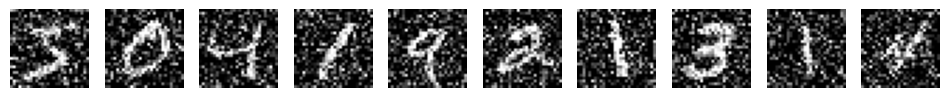

In [17]:
plt.figure(figsize=(12,2))

for i in range(10):

    plt.subplot(1,10,i+1)

    plt.imshow(train_noisy[i].squeeze(), cmap='gray')

    plt.axis('off')

plt.show()

## Compare Original and Noisy Images

The figure below provides a side-by-side comparison of clean and noisy images. This helps verify that Gaussian noise has been correctly introduced before training the autoencoder.

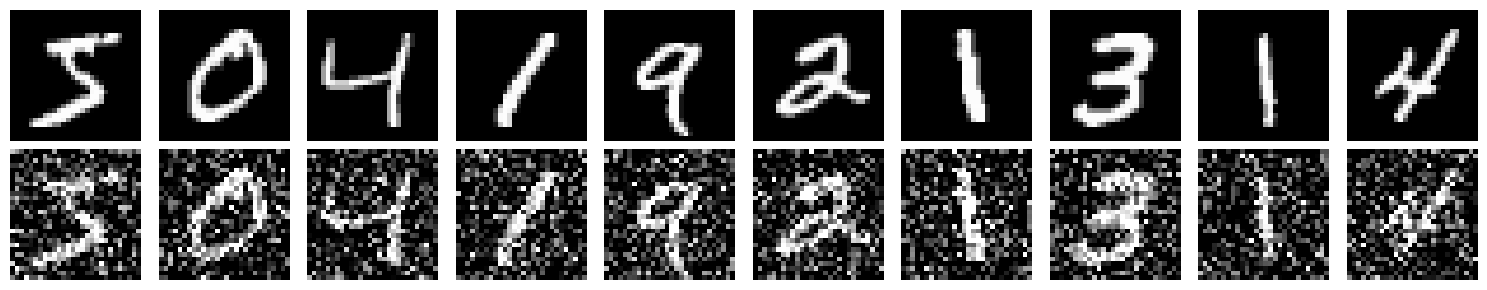

In [18]:
fig, axes = plt.subplots(2, 10, figsize=(15,3))

for i in range(10):

    # Original images
    axes[0, i].imshow(train_images[i].squeeze(), cmap='gray')
    axes[0, i].axis('off')

    # Noisy images
    axes[1, i].imshow(train_noisy[i].squeeze(), cmap='gray')
    axes[1, i].axis('off')

axes[0,0].set_ylabel("Original", fontsize=12)
axes[1,0].set_ylabel("Noisy", fontsize=12)

plt.tight_layout()
plt.show()

## Create Training and Testing DataLoaders

The model requires batches of data during training. Therefore, the noisy images are paired with their corresponding clean images.

Each training sample consists of:

- **Input:** Noisy image
- **Target:** Clean image

In [39]:
batch_size = 20

# Create TensorDatasets
train_tensor = TensorDataset(train_noisy, train_images)
test_tensor = TensorDataset(test_noisy, test_images)


In [40]:
from torch.utils.data import random_split

# Split the training dataset into 80% training and 20% validation
train_size = int(0.8 * len(train_tensor))
valid_size = len(train_tensor) - train_size

train_subset, valid_subset = random_split(train_tensor,[train_size, valid_size])

train_loader = DataLoader(train_subset,batch_size=batch_size,shuffle=True)

valid_loader = DataLoader(valid_subset,batch_size=batch_size,shuffle=False)

test_loader = DataLoader(test_tensor,batch_size=batch_size,shuffle=False)

In [41]:
print("Training batches  :", len(train_loader))
print("Validation batches:", len(valid_loader))
print("Testing batches   :", len(test_loader))

for noisy, clean in valid_loader:
    print("Validation Input :", noisy.shape)
    print("Validation Target:", clean.shape)
    break

Training batches  : 2400
Validation batches: 600
Testing batches   : 500
Validation Input : torch.Size([20, 1, 28, 28])
Validation Target: torch.Size([20, 1, 28, 28])


# Build the Convolutional Denoising Autoencoder

An autoencoder consists of two major components:

### 1. Encoder
The encoder compresses the noisy input image into a lower-dimensional latent representation while preserving the most important features.

### 2. Decoder
The decoder reconstructs the clean image from this compressed representation.

Since MNIST images contain spatial information, convolutional layers are used instead of fully connected layers. This allows the model to learn local patterns such as edges, curves, and digit structures more effectively.

### Architecture

Encoder:

- Conv2D (1 → 16)
- ReLU
- MaxPooling
- Conv2D (16 → 32)
- ReLU
- MaxPooling

Decoder:

- ConvTranspose2D (32 → 16)
- ReLU
- ConvTranspose2D (16 → 1)
- Sigmoid

The final Sigmoid activation ensures that the reconstructed pixel values remain within the range **[0,1]**.

In [42]:
class DenoisingAutoencoder(nn.Module):
    def __init__(self):
        super(DenoisingAutoencoder, self).__init__()

        #Encoder
        self.encoder = nn.Sequential(
            nn.Conv2d(in_channels=1,out_channels=16,kernel_size=3,padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Conv2d(in_channels=16,out_channels=32,kernel_size=3,padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )

        # Decoder
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(in_channels=32,out_channels=16,kernel_size=2,stride=2),
            nn.ReLU(),
            nn.ConvTranspose2d(in_channels=16,out_channels=1,kernel_size=2,stride=2),
            nn.Sigmoid()
        )

    def forward(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded

## Initialize the Model

The denoising autoencoder is initialized and moved to the available computation device.

If a CUDA-enabled GPU is available, the model will automatically utilize it to accelerate the training process. Otherwise, training will be performed on the CPU.

In [43]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using Device :", device)

model = DenoisingAutoencoder().to(device)

Using Device : cpu


## Display Model Architecture

Printing the model architecture provides a clear overview of the encoder and decoder components, including the sequence of convolutional, pooling, and transposed convolution layers used for image compression and reconstruction.

In [44]:
print(model)

DenoisingAutoencoder(
  (encoder): Sequential(
    (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (decoder): Sequential(
    (0): ConvTranspose2d(32, 16, kernel_size=(2, 2), stride=(2, 2))
    (1): ReLU()
    (2): ConvTranspose2d(16, 1, kernel_size=(2, 2), stride=(2, 2))
    (3): Sigmoid()
  )
)


# Define the Loss Function and Optimizer

The model is trained by minimizing the difference between the reconstructed image and the original clean image.

### Loss Function

**Mean Squared Error (MSE)** is selected because image denoising is a pixel-wise reconstruction task. It penalizes large reconstruction errors and encourages the model to generate images that closely resemble the original inputs.

### Optimizer

The **Adam optimizer** is used because it provides adaptive learning rates and generally converges faster than traditional optimization algorithms for deep learning tasks.

In [45]:
criterion = nn.MSELoss()

optimizer = optim.Adam(model.parameters(),lr=0.001)

In [46]:
print("\nModel Summary")

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Total Parameters     : {total_params:,}")
print(f"Trainable Parameters : {trainable_params:,}")


Model Summary
Total Parameters     : 6,929
Trainable Parameters : 6,929


# Training the Denoising Autoencoder

The model is trained using noisy images as inputs and the corresponding clean images as target outputs.

During each epoch:

- Forward propagation generates reconstructed images.
- The reconstruction loss is computed using Mean Squared Error (MSE).
- Backpropagation updates the model weights using the Adam optimizer.
- Validation loss is calculated after every epoch to monitor generalization performance.
- The model with the lowest validation loss is automatically saved.

In [47]:
def train_model(model,train_loader,valid_loader,criterion,optimizer,epochs=20):
    train_losses = []
    valid_losses = []

    best_valid_loss = float("inf")

    for epoch in range(epochs):

        # Training
        model.train()
        running_train_loss = 0.0
        for noisy_images, clean_images in train_loader:
            noisy_images = noisy_images.to(device)
            clean_images = clean_images.to(device)
            optimizer.zero_grad()
            outputs = model(noisy_images)
            loss = criterion(outputs, clean_images)
            loss.backward()
            optimizer.step()
            running_train_loss += loss.item()

        # Validation
        model.eval()
        running_valid_loss = 0.0
        with torch.no_grad():
            for noisy_images, clean_images in valid_loader:
                noisy_images = noisy_images.to(device)
                clean_images = clean_images.to(device)
                outputs = model(noisy_images)
                loss = criterion(outputs, clean_images)
                running_valid_loss += loss.item()

        train_loss = running_train_loss / len(train_loader)
        valid_loss = running_valid_loss / len(valid_loader)

        train_losses.append(train_loss)
        valid_losses.append(valid_loss)

        print(
            f"Epoch [{epoch+1}/{epochs}] "
            f"Training Loss: {train_loss:.6f} "
            f"Validation Loss: {valid_loss:.6f}"
        )

        # Save Best Model

        if valid_loss < best_valid_loss:
            best_valid_loss = valid_loss
            torch.save(
                model.state_dict(),
                "best_denoising_autoencoder.pth"
            )
            print("Best model saved!")

    return train_losses, valid_losses

## Train the Model

In [48]:
train_losses, valid_losses = train_model(model,train_loader,valid_loader,criterion,optimizer,epochs=20)

Epoch [1/20] Training Loss: 0.022999 Validation Loss: 0.012495
Best model saved!
Epoch [2/20] Training Loss: 0.011926 Validation Loss: 0.011453
Best model saved!
Epoch [3/20] Training Loss: 0.011284 Validation Loss: 0.011012
Best model saved!
Epoch [4/20] Training Loss: 0.010939 Validation Loss: 0.010831
Best model saved!
Epoch [5/20] Training Loss: 0.010733 Validation Loss: 0.010673
Best model saved!
Epoch [6/20] Training Loss: 0.010586 Validation Loss: 0.010490
Best model saved!
Epoch [7/20] Training Loss: 0.010469 Validation Loss: 0.010412
Best model saved!
Epoch [8/20] Training Loss: 0.010374 Validation Loss: 0.010325
Best model saved!
Epoch [9/20] Training Loss: 0.010291 Validation Loss: 0.010296
Best model saved!
Epoch [10/20] Training Loss: 0.010221 Validation Loss: 0.010167
Best model saved!
Epoch [11/20] Training Loss: 0.010160 Validation Loss: 0.010160
Best model saved!
Epoch [12/20] Training Loss: 0.010110 Validation Loss: 0.010164
Epoch [13/20] Training Loss: 0.010066 Valid

# Load the Best Model

Instead of using the model from the final training epoch, the saved model with the lowest validation loss is loaded.

This helps ensure that evaluation is performed using the model that generalized best to unseen data.

In [49]:
model.load_state_dict(
    torch.load(
        "best_denoising_autoencoder.pth",
        map_location=device
    )
)

model.eval()

print("Best model loaded successfully.")

Best model loaded successfully.


# Training Performance

During training, both the training loss and validation loss were monitored after each epoch.

A decreasing trend in both losses indicates that the model is learning to reconstruct clean images from noisy inputs while maintaining good generalization performance.

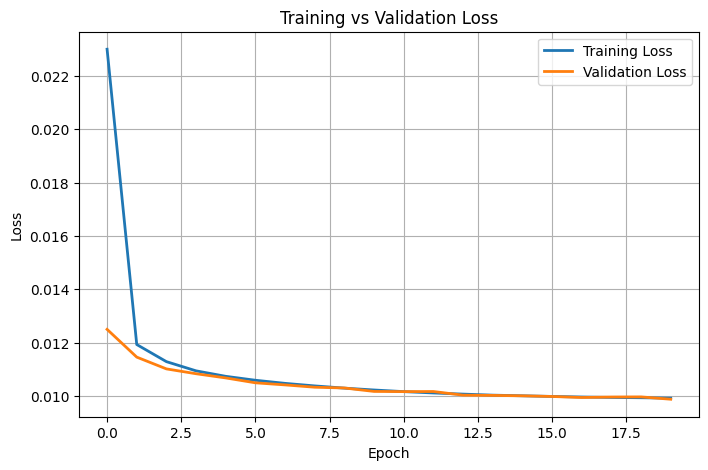

In [50]:
plt.figure(figsize=(8,5))

plt.plot(train_losses, label='Training Loss', linewidth=2)
plt.plot(valid_losses, label='Validation Loss', linewidth=2)

plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.show()

# Generate Denoised Images

The trained autoencoder is evaluated on the unseen test dataset.

Noisy test images are passed through the encoder-decoder network to generate reconstructed (denoised) images.

In [51]:
model.eval()

denoised_images = []

with torch.no_grad():

    for noisy_images, _ in test_loader:

        noisy_images = noisy_images.to(device)

        outputs = model(noisy_images)

        denoised_images.append(outputs.cpu())

denoised_images = torch.cat(denoised_images)

# Visual Comparison

The following figure compares:

- Original Image
- Noisy Image
- Denoised (Reconstructed) Image

This visual comparison helps evaluate how effectively the autoencoder removes Gaussian noise while preserving the digit structure.

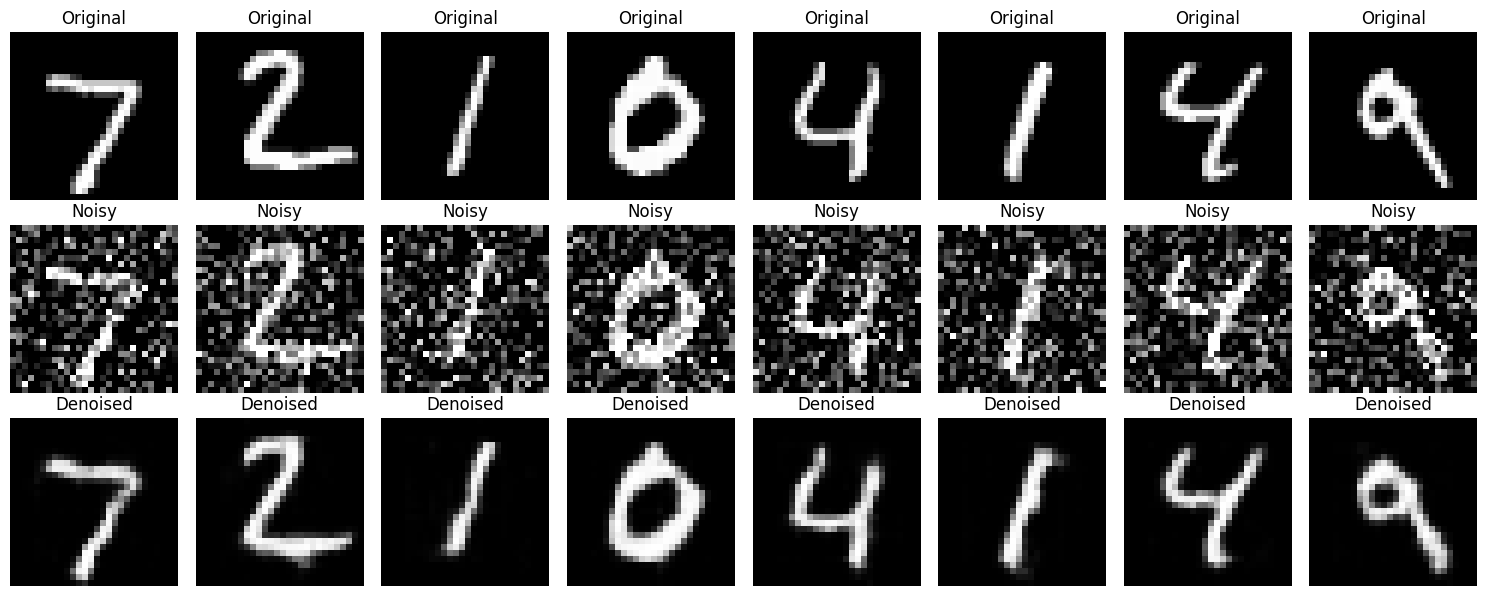

In [52]:
n = 8

plt.figure(figsize=(15,6))

for i in range(n):

    # Original Images
    ax = plt.subplot(3, n, i + 1)
    plt.imshow(test_images[i].squeeze(), cmap='gray')
    plt.title("Original")
    plt.axis("off")

    # Noisy Images
    ax = plt.subplot(3, n, i + 1 + n)
    plt.imshow(test_noisy[i].squeeze(), cmap='gray')
    plt.title("Noisy")
    plt.axis("off")

    # Denoised Images
    ax = plt.subplot(3, n, i + 1 + 2*n)
    plt.imshow(denoised_images[i].squeeze(), cmap='gray')
    plt.title("Denoised")
    plt.axis("off")

plt.tight_layout()
plt.show()

# Quantitative Evaluation

To objectively measure the reconstruction quality, the following evaluation metrics are calculated:

- **Mean Squared Error (MSE):** Measures the average squared difference between the reconstructed and original images.
- **Peak Signal-to-Noise Ratio (PSNR):** Measures reconstruction quality in decibels. Higher PSNR values indicate better image reconstruction.

In [53]:
from sklearn.metrics import mean_squared_error

mse = mean_squared_error(
    test_images.numpy().flatten(),
    denoised_images.numpy().flatten()
)

print(f"Mean Squared Error (MSE): {mse:.6f}")

Mean Squared Error (MSE): 0.009743


In [54]:
def calculate_psnr(original, reconstructed):

    mse = np.mean((original - reconstructed) ** 2)

    if mse == 0:
        return float("inf")

    max_pixel = 1.0

    psnr = 20 * np.log10(max_pixel / np.sqrt(mse))

    return psnr


psnr_value = calculate_psnr(
    test_images.numpy(),
    denoised_images.numpy()
)

print(f"PSNR: {psnr_value:.2f} dB")

PSNR: 20.11 dB


# Performance Summary

The obtained evaluation metrics provide a quantitative assessment of the denoising autoencoder.

- A **lower MSE** indicates that the reconstructed images are closer to the original images.
- A **higher PSNR** reflects better reconstruction quality and more effective noise removal.
- Along with the visual comparisons, these metrics demonstrate the model's ability to preserve important digit features while reducing Gaussian noise.

# Effect of Different Noise Levels

One of the important factors affecting the performance of a denoising autoencoder is the amount of noise added to the input images.

To study this effect, different Gaussian noise levels were experimented with.

| Noise Factor | Observation |
|--------------|-------------|
| 0.2 | Images contain very little noise and are reconstructed almost perfectly. |
| 0.4 | Good balance between noise removal and preservation of digit structure. |
| 0.6 | Images become highly corrupted, making reconstruction significantly more difficult. |

This experiment demonstrates how the level of corruption influences the reconstruction capability of the autoencoder.

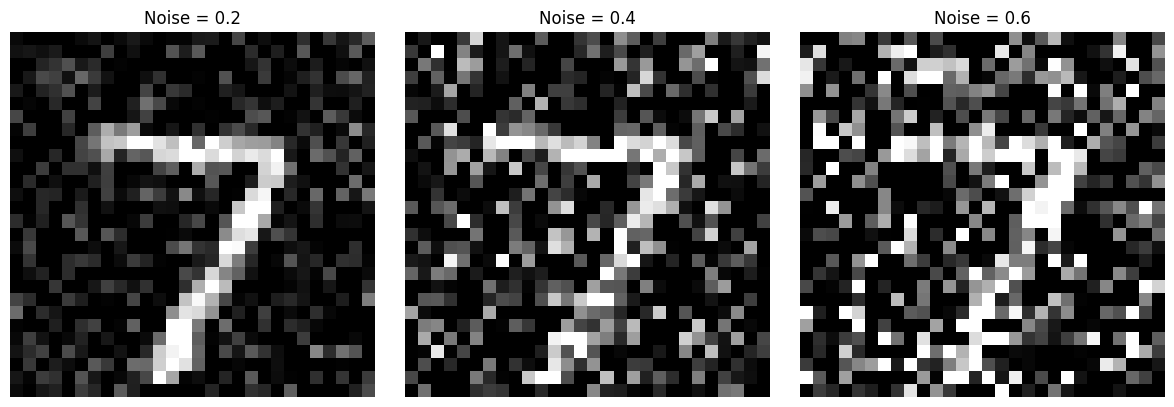

In [55]:
noise_levels = [0.2, 0.4, 0.6]

plt.figure(figsize=(12,4))

sample = test_images[0]

for i, noise in enumerate(noise_levels):

    noisy = add_noise(sample.unsqueeze(0), noise)

    plt.subplot(1,3,i+1)

    plt.imshow(noisy.squeeze(), cmap="gray")

    plt.title(f"Noise = {noise}")

    plt.axis("off")

plt.tight_layout()

plt.show()

# Key Observations

The following observations were made during the implementation and evaluation of the denoising autoencoder:

- The model successfully learned to remove Gaussian noise from handwritten digit images.
- Convolutional layers preserved important spatial information better than fully connected layers.
- Training and validation losses consistently decreased, indicating effective learning.
- The reconstructed images retained the overall digit structure while removing a significant amount of noise.
- Higher noise levels increased the reconstruction difficulty, resulting in slightly blurred outputs.
- The model generalized well on previously unseen test images.

# Challenges Faced

Several challenges were encountered while developing the denoising autoencoder:

- Selecting an appropriate Gaussian noise level without making the reconstruction task excessively difficult.
- Choosing an encoder-decoder architecture that balances reconstruction quality and computational efficiency.
- Preventing overfitting while maintaining good reconstruction performance.
- Ensuring that reconstructed images preserved the original digit structure after denoising.
- Optimizing the model to achieve low reconstruction loss within a limited number of training epochs.